# QF 627 Programming and Computational Finance
## Problem Set `9` | `Questions`

> Hi Team, 👋

> Having reviewed your submissions so far, some of the questions below have been crafted specifically to enhance your grasp of the course material.

> I trust that the exercises below will support your review and understanding of the course content. 🤞

#### <font color = "green"> Please submit your answers via the eLearn submission folder. Again, you may submit incomplete answers. (Answer as fully as you can. This will help me to see where you stand.)

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [139]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [140]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

%matplotlib inline

## 👇 <font color = "purple"> Bigger Question 1. 
    
### The first question is to look for clusters of correlations using the agglomerate hierarchical clustering technique (AGNES).
    
### <font color = green> Using the 102 tickers below, and what you have learned in class, run the analysis and develop a dendrogram. Make sure to employ the inclusion criterion of less than 30% of missing values.
    
    According to the dendrogram, which of the stocks are most correlated? 
    
    Also based on the dendrogram, please identify two stocks that are not well correlated.

In [141]:
nasdaq100_components = pd.read_html("https://stockanalysis.com/list/nasdaq-100-stocks/")[0].iloc[ : , 1: ]

nasdaq100_components

,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue
0,NVDA,NVIDIA Corporation,4.57T,188.08,-3.65%,165.22B
1,AAPL,Apple Inc.,3.99T,269.77,-0.14%,416.16B
2,MSFT,Microsoft Corporation,3.69T,497.10,-1.98%,293.81B
3,GOOG,Alphabet Inc.,3.44T,285.34,0.21%,385.48B
4,GOOGL,Alphabet Inc.,3.44T,284.75,0.15%,385.48B
...,...,...,...,...,...,...
96,TTD,"The Trade Desk, Inc.",22.44B,45.90,-3.77%,2.79B
97,ON,ON Semiconductor Corporation,19.64B,48.80,-2.56%,6.19B
98,LULU,lululemon athletica inc.,19.39B,163.55,-2.41%,10.90B
99,GFS,GlobalFoundries Inc.,19.10B,34.42,-3.40%,6.84B


In [142]:
tickers = nasdaq100_components['Symbol'].to_list()

# TODO yf download
stock_data=\
yf.download(
    tickers,
    start = '2015-01-01',
    threads = True
)['Close']


[*********************100%***********************]  101 of 101 completed


In [143]:
missing = stock_data.isnull().mean().sort_values()
drop_list = missing[missing>.3].index.to_list()
stock_data =\
    stock_data.drop(labels=drop_list, axis=1)
stock_data = stock_data.fillna(method="ffill").dropna()

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 1 is presented in the cell below: </font>

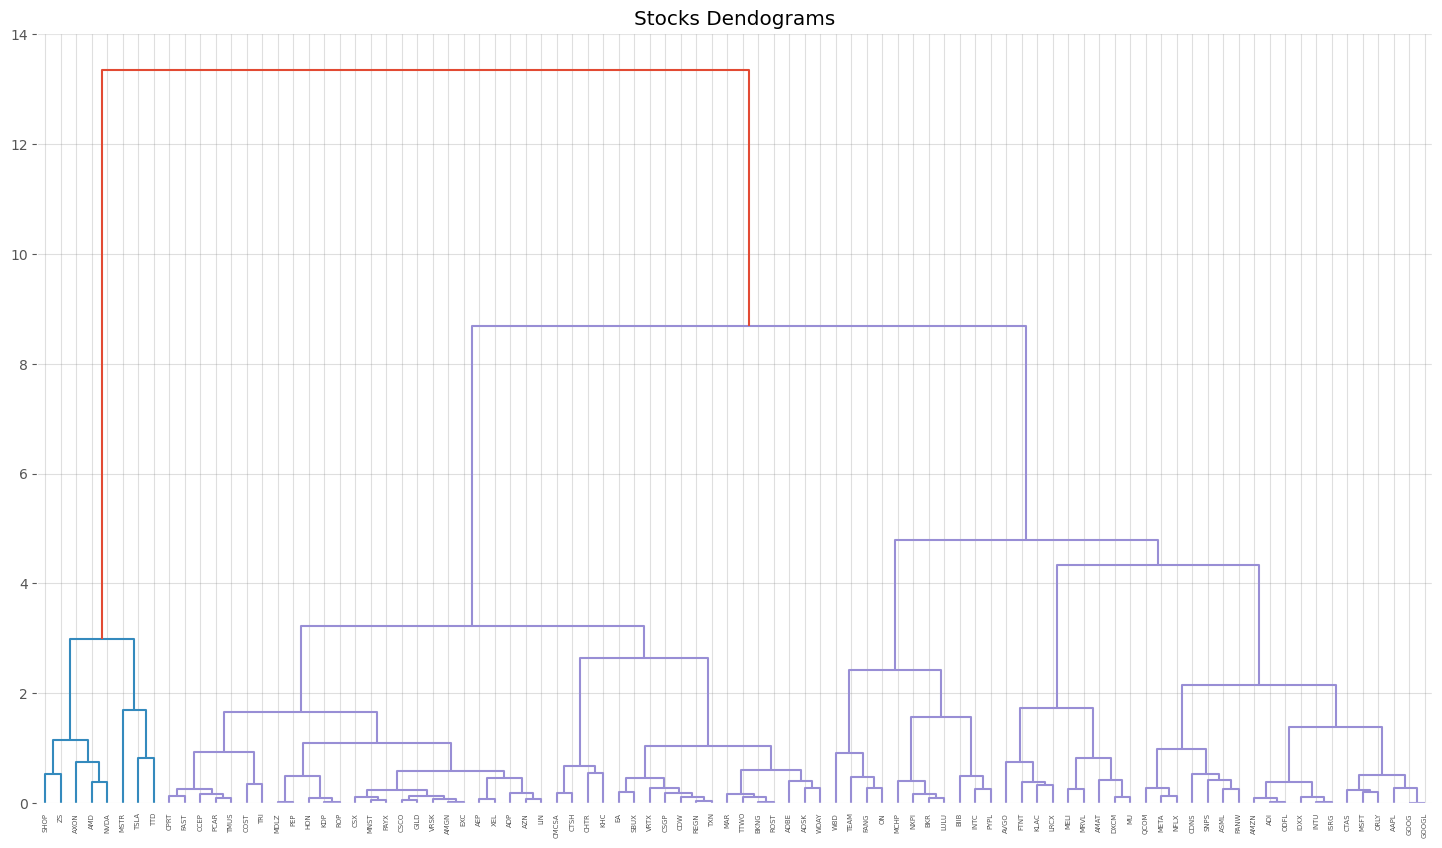

In [144]:
# ----------------------------------------------------------------------------
# agnes get_agnes agglo
# ----------------------------------------------------------------------------


# prepare annual returns
ann_rets = stock_data.pct_change().mean() * 252
# prepare volatiltiy
vol = stock_data.pct_change().std(ddof=1) * np.sqrt(252)

df = \
(
    pd.DataFrame({'return': ann_rets, 'volatility': vol})
)

# hierarchical cluster
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data = scaler.fit_transform(df)

df = pd.DataFrame(data, columns=df.columns, index=df.index)

X = df.copy()

# model fit
from scipy.cluster.hierarchy import dendrogram, linkage, ward
#Calulate linkage
Z = linkage(X, 
            method = "ward")
# Plot Dendogram

plt.figure(figsize=(18, 10)
          )
plt.title("Stocks Dendograms")

dendrogram(Z, labels = X.index)

plt.show()

GOOGL and ZS

array([3, 2, 1], dtype=int32)

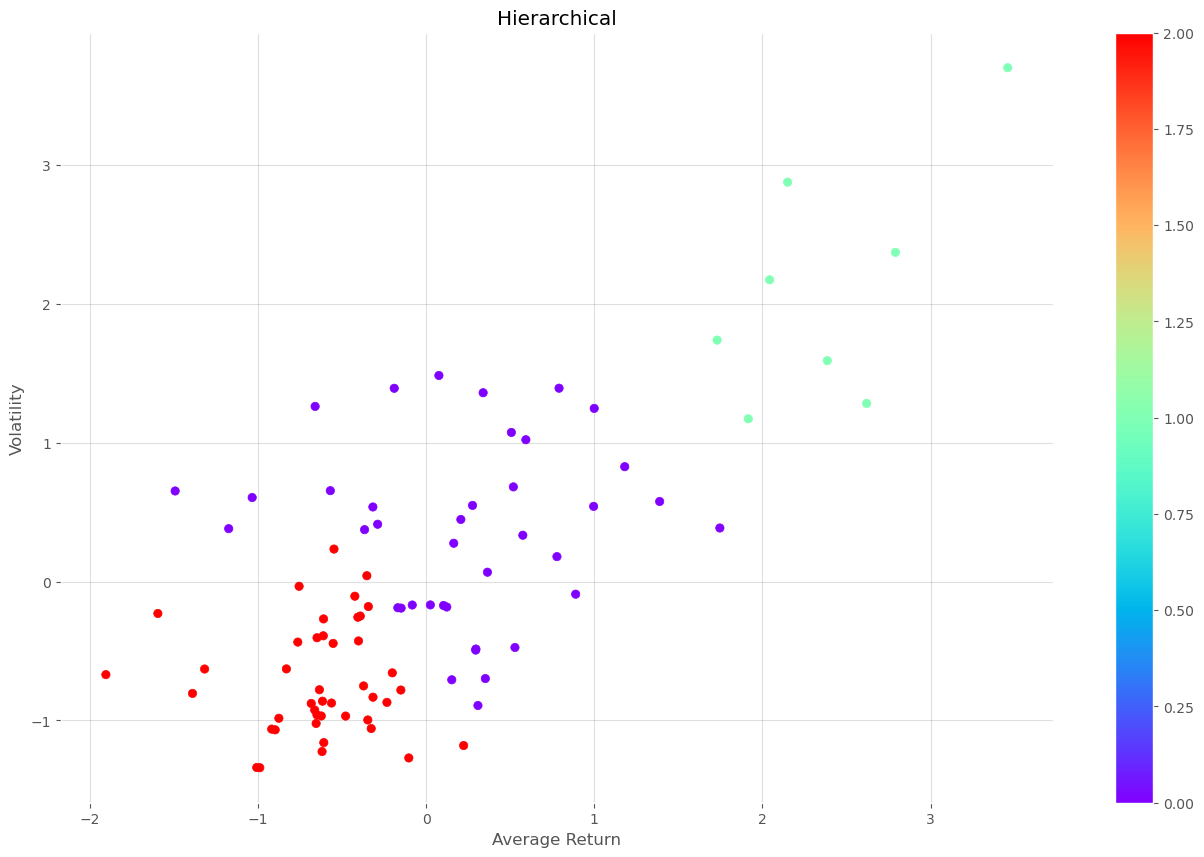

In [145]:
from sklearn.cluster import AgglomerativeClustering
# from sklearn.cluster import KMeans, AgglomerativeClustering,AffinityPropagation, DBSCAN
from scipy.cluster.hierarchy import fcluster
# from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
# from scipy.spatial.distance import pdist
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn import cluster, covariance, manifold

# choose a cluster from the longest vertical line
distance_threshold = 7

clusters = fcluster(Z, distance_threshold, criterion='distance')

chosen_clusters = pd.DataFrame(data=clusters, 
                               columns=['cluster']
                              )
display(chosen_clusters['cluster'].unique())

# do the transformation to assign clusters
# agglomarative clustering
nclust = 3

hc = AgglomerativeClustering(n_clusters = nclust, 
                             linkage = "ward")

clust_labels1 = hc.fit_predict(X)

#visualisation
fig = plt.figure(figsize=[16,10]
)

ax = fig.add_subplot(111)

scatter = ax.scatter(X.iloc[:,0], 
                     X.iloc[:,1], 
                     c = clust_labels1, 
                     cmap = "rainbow")

ax.set_title("Hierarchical")
ax.set_xlabel("Average Return")
ax.set_ylabel("Volatility")

plt.colorbar(scatter)

## 👇 <font color = "purple"> Bigger Question 2. ### 

### The second question asks you to run a principal components analysis (PCA) for portfolio management. Begin your analysis with all the above stocks. Make sure to employ the inclusion criterion of less than 30% of missing values.
    
    Your objective is to find the portfolio using PCA.
    
    Select and normalize the four largest components and use them as weights for 
    portfolios that you can compare to an equal-weighted portfolio comprising all stocks.
    
    Identify the profile of the portfolio based on the portfolio weights.
    
    When comparing the performance of each portfolio over the sample period 
    to "the market", assess the performance of other portfolios that capture different 
    return patterns.
    
> Please use 75% of your data for PCA and 25% for backtesting.    
    
### <font color = "green"> NOTE: The investment horizon will be 10 years between 2010 and 2019.

### Below are the lines of code that lead to an answer:

In [23]:
tickers = nasdaq100_components['Symbol'].to_list()

# TODO yf download
stock_data=\
yf.download(
    tickers,
    start = '2009-01-01',
    threads = True
)['Close']


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_58780/3520561983.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  101 of 101 completed


In [16]:
returns_df = stock_data.pct_change().dropna()

In [24]:
missing = stock_data.isnull().mean().sort_values()
drop_list = missing[missing>.3].index.to_list()
stock_data =\
    stock_data.drop(labels=drop_list, axis=1)
stock_data = stock_data.fillna(method="ffill").dropna()
stock_data.pct_change().mean()

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_58780/4257658960.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_data = stock_data.fillna(method="ffill").dropna()


Ticker
AAPL    0.001158
ADBE    0.000840
ADI     0.000800
ADP     0.000646
ADSK    0.000927
          ...   
VRSK    0.000529
VRTX    0.000788
WBD     0.000213
WDAY    0.000695
XEL     0.000544
Length: 84, dtype: float64

In [25]:
returns_df.isnull().sum().sum()

0

In [26]:
# ----------------------------------------------------------------------------
# PCA get_pca
# ----------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA


x = returns_df
RANDOM_SEED=42
NumEigenValues = 10
NumComponents = 4
x_train_raw, x_test_raw = train_test_split(x, test_size=0.2, random_state=RANDOM_SEED, shuffle=False)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw) 
x_test = scaler.transform(x_test_raw)       # keep raw for actual resutls later

pca = PCA()
PrincipalComponent = pca.fit(x_train)

def PCWeights(pca_):

    weights = pd.DataFrame()

    for i in range(len(pca_.components_)
                  ):
        # w = pca_.components_[i] - pca_.components_[i].mean()
        # w = w / sum(abs(w))
        weights["weights_{}".format(i)] = pca_.components_[i] / sum(pca_.components_[i])

    weights = weights.values.T
    return weights # Team, be careful with indentation    
    # return w # Team, be careful with indentation


weights = PCWeights(pca) 


topPortfolios =\
(
    pd
    .DataFrame(pca.components_[ : NumComponents],
               columns = x.columns)
)

eigen_portfolios =\
(
    topPortfolios
    .div(topPortfolios.sum(axis=1), # normalising step
         axis = 0)
)

eigen_portfolios.index = [f"Portfolio {i}" for i in range(NumComponents)
                         ]
np.sqrt(pca.explained_variance_)

array([6.193, 2.359, 1.867, 1.515, 1.302, 1.17 , 1.155, 1.052, 1.04 ,
       1.032, 0.98 , 0.946, 0.939, 0.905, 0.896, 0.873, 0.87 , 0.861,
       0.851, 0.84 , 0.834, 0.819, 0.799, 0.795, 0.786, 0.781, 0.768,
       0.76 , 0.754, 0.745, 0.73 , 0.724, 0.719, 0.71 , 0.703, 0.694,
       0.693, 0.685, 0.677, 0.673, 0.668, 0.663, 0.659, 0.647, 0.642,
       0.638, 0.636, 0.626, 0.621, 0.615, 0.608, 0.607, 0.598, 0.592,
       0.583, 0.577, 0.575, 0.57 , 0.568, 0.567, 0.555, 0.552, 0.547,
       0.542, 0.533, 0.527, 0.525, 0.518, 0.51 , 0.507, 0.496, 0.492,
       0.479, 0.474, 0.461, 0.454, 0.44 , 0.436, 0.423, 0.416, 0.408,
       0.398, 0.383, 0.374, 0.346, 0.337, 0.332, 0.315, 0.274, 0.067])

In [27]:
def calculate_sharpe_ratio(ts_returns, periods_per_year = 252):

    n_years = ts_returns.shape[0] / periods_per_year

    annualized_return = np.power(np.prod(1 + ts_returns), (1 / n_years)
                                ) - 1

    annualized_vol = ts_returns.std() * np.sqrt(periods_per_year)

    annualized_sharpe = annualized_return / annualized_vol

    return annualized_return, annualized_vol, annualized_sharpe

def valid_backtest_PCA_porfolios(eigen):
    
    eigen_prtfi =\
        (
            pd
            .DataFrame(data = {"weights": eigen.squeeze()
                              },
                       index = stock_tickers)
        )

    # Sanity Check: Ensure the order of tickers in X_Test_Raw matches the order in eigen
    if not list(eigen_prtfi.index) == stock_tickers: 
        raise ValueError("Sanity check failed: Mismatch in number of tickers between X_Test_Raw and eigen.")
    else:
        print("Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.")
    
    # Let's directly compute the dot product without sorting
    eigen_prtfi_returns =\
    (
        np
        .dot(X_Test_Raw, eigen)
    )
    
    eigen_portfolio_returns =\
    (
        pd
        .Series(eigen_prtfi_returns.squeeze(),
                index = x_test_index)
    )

    returns, vol, sharpe = calculate_sharpe_ratio(eigen_portfolio_returns)

    print("Our PCA-based Portfolio:\nReturn = %.2f%%\nVolatility = %.2f%%\nSharpe = %.2f"  %
          (returns * 100, vol * 100, sharpe)
         )

    # Compared with what? Equal-weightage Portfolio

    equal_weight_return =\
    (
        X_Test_Raw * (1 / len(pca.components_)
                     )
    ).sum(axis = 1)

    df_plot =\
        (
            pd
            .DataFrame({"ML Portfolio Return": eigen_portfolio_returns,
                        "Equal Weight Index": equal_weight_return},
                      index = x_test_index
                      )
        )

    (
        np
        .cumprod(df_plot + 1)
        .plot(title = "Returns of the equal weighted index vs. Eigen-Portfolio",
              figsize = [16, 8]
             )
    )

    plt.show()
    
    return returns, vol, sharpe

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = 16.44%
Volatility = 19.68%
Sharpe = 0.84


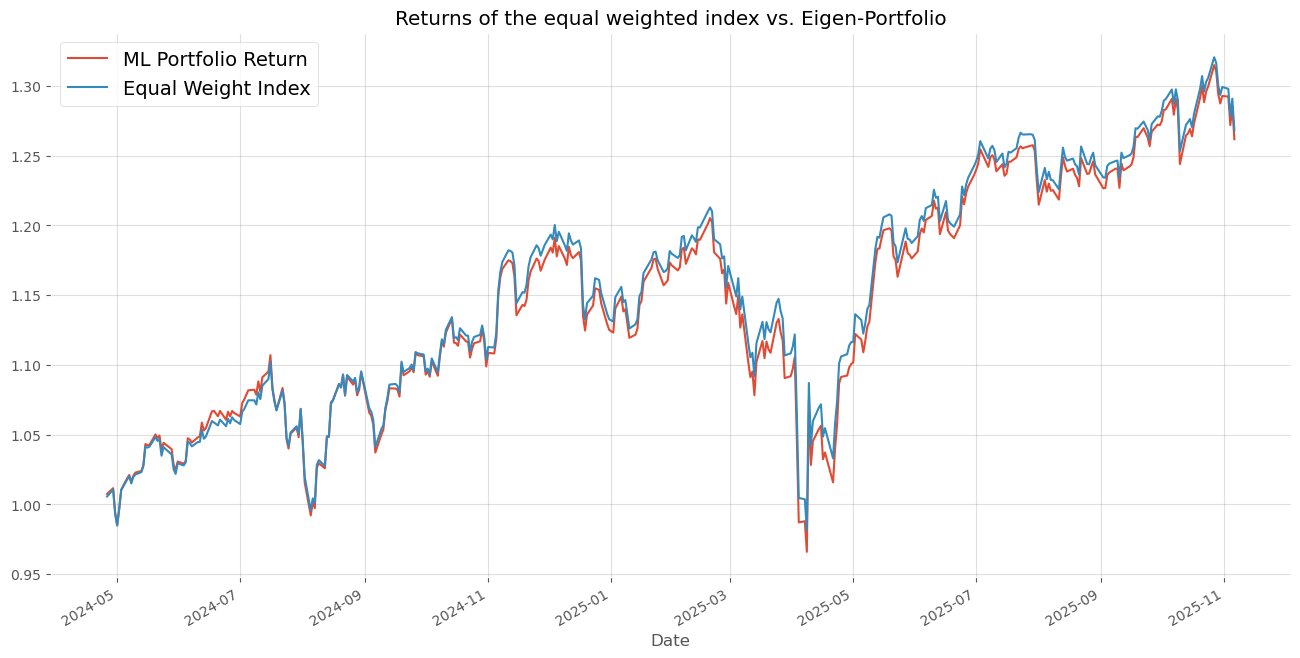

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -93.56%
Volatility = 171.12%
Sharpe = -0.55


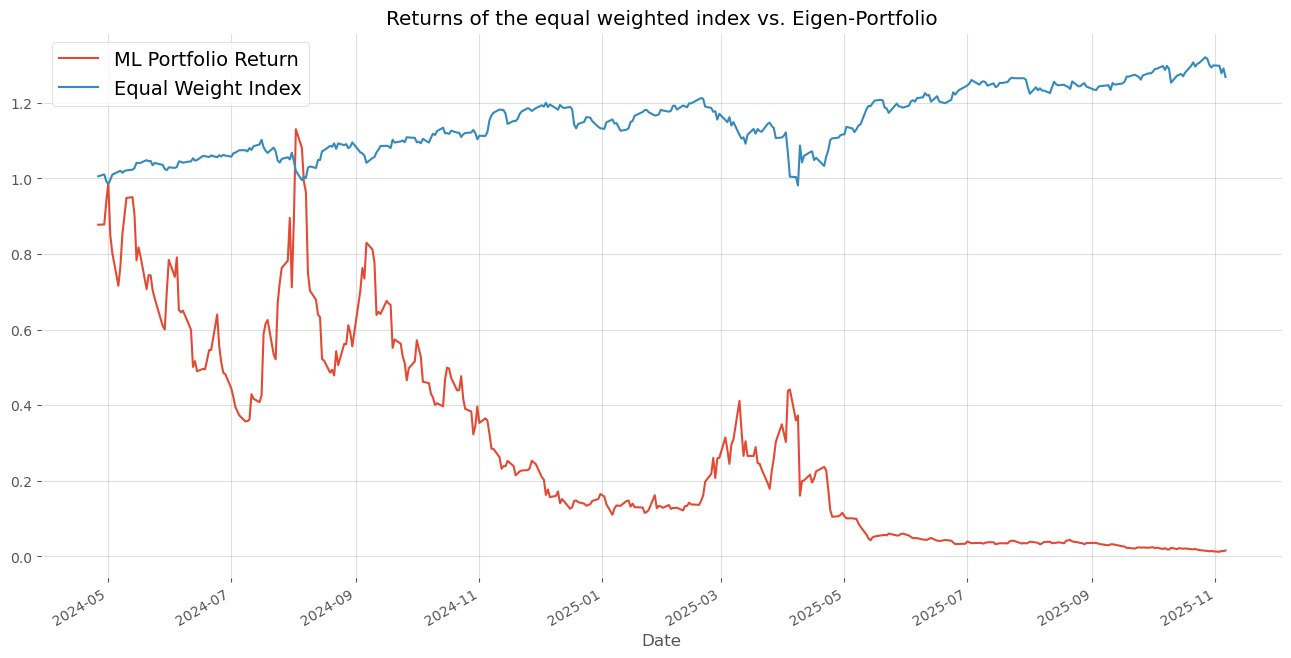

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -73.07%
Volatility = 147.90%
Sharpe = -0.49


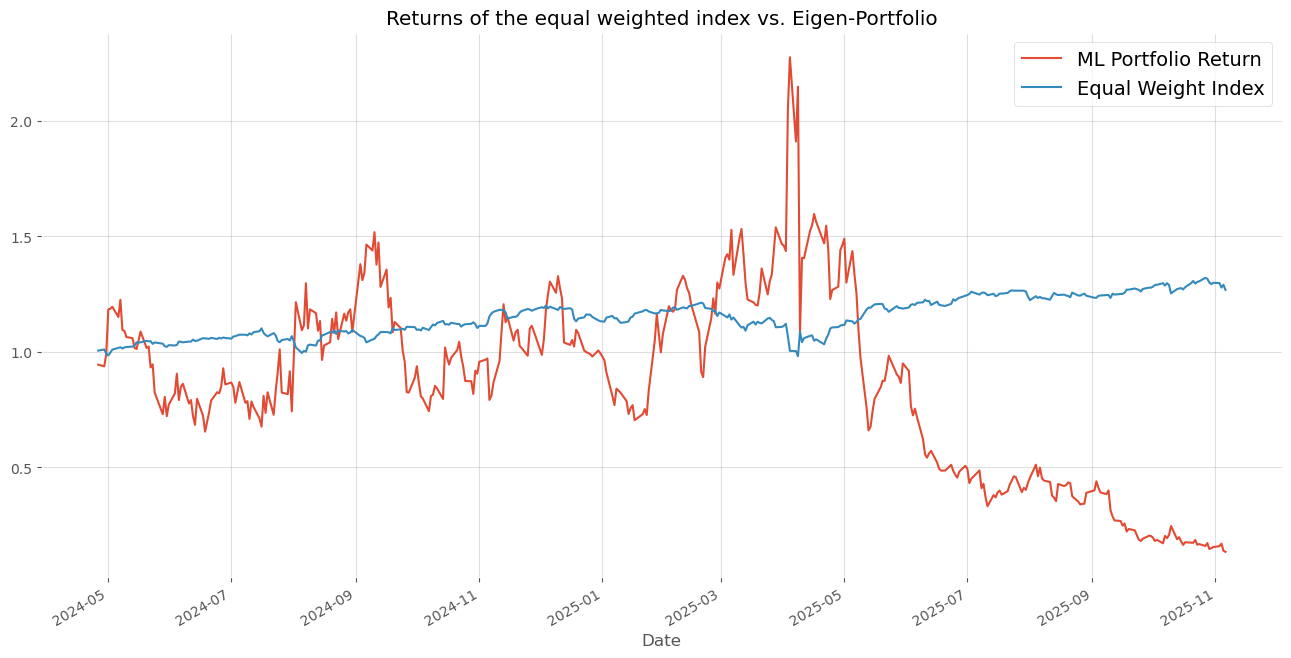

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -99.78%
Volatility = 297.04%
Sharpe = -0.34


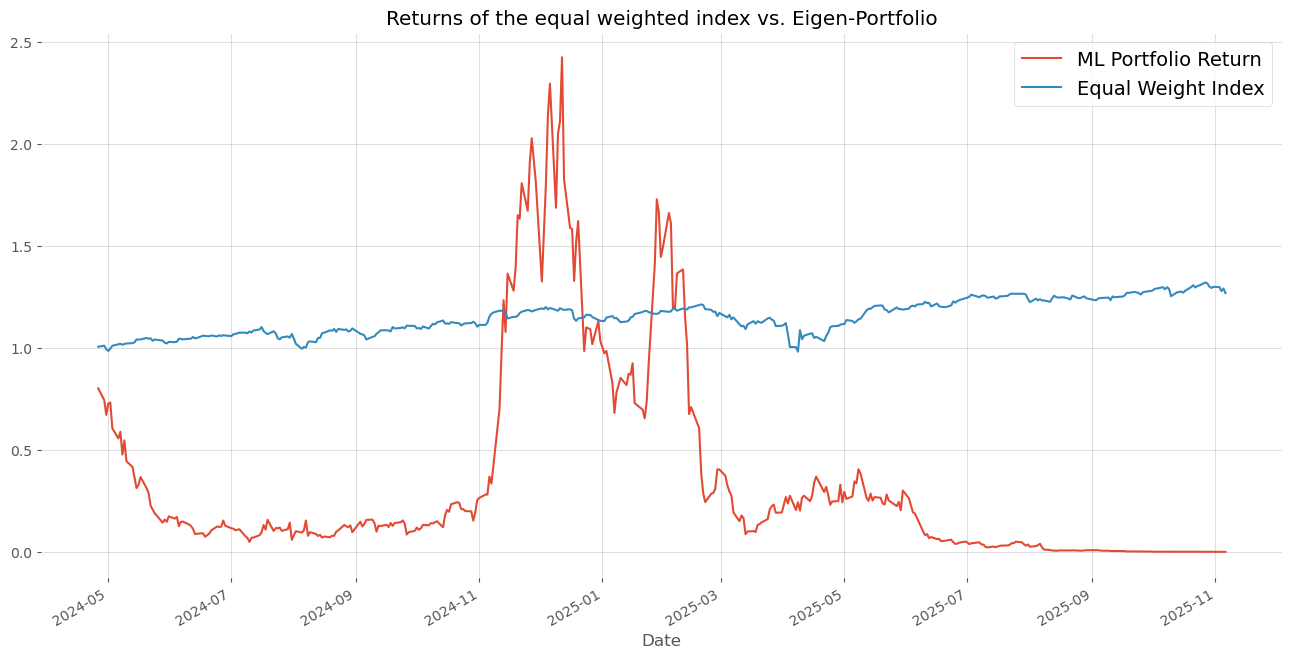

In [28]:
stock_tickers = x.columns.to_list()
X_Test_Raw = x_test_raw
x_test_index = x.iloc[len(x_train):].index


res_ls = []
for idx in range(4):
    rets, vol, sharpe = valid_backtest_PCA_porfolios(eigen = weights[idx])
    res_ls.append((rets, vol, sharpe))

### <font color = red> Answer 2 is presented in the cell below: </font>

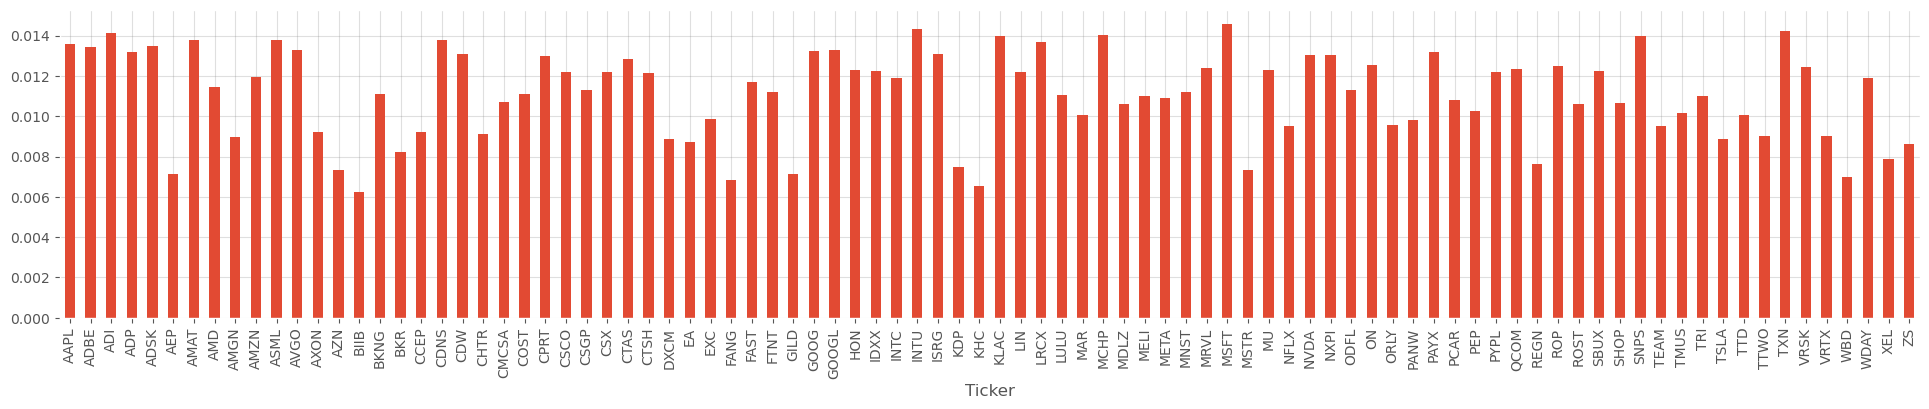

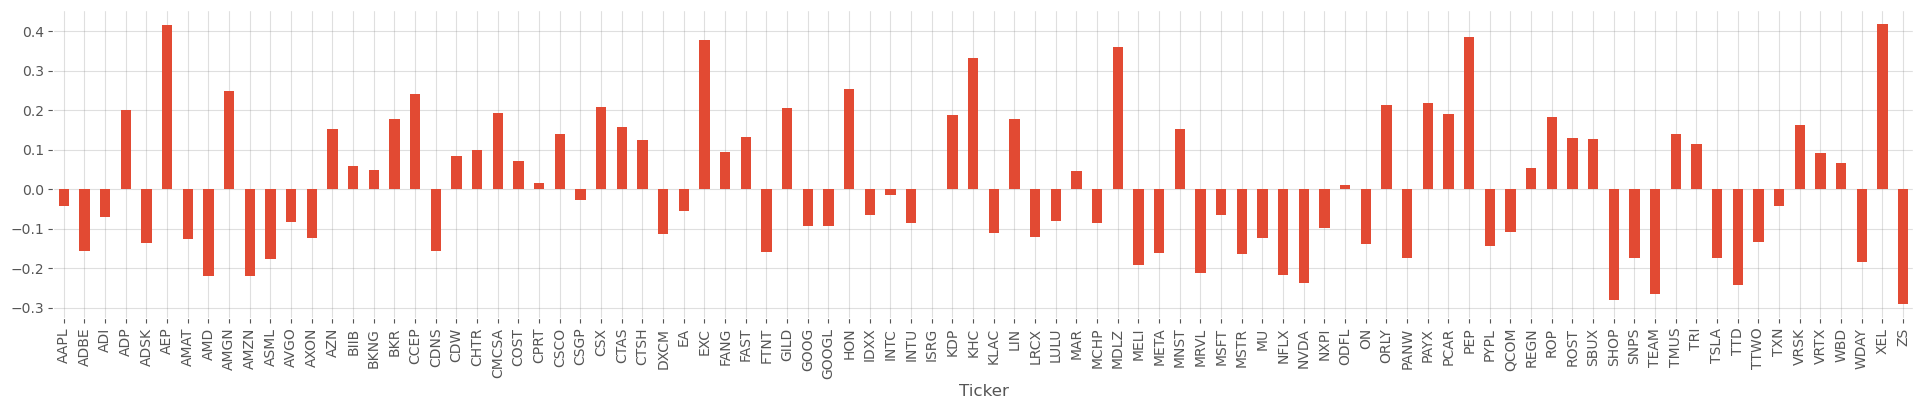

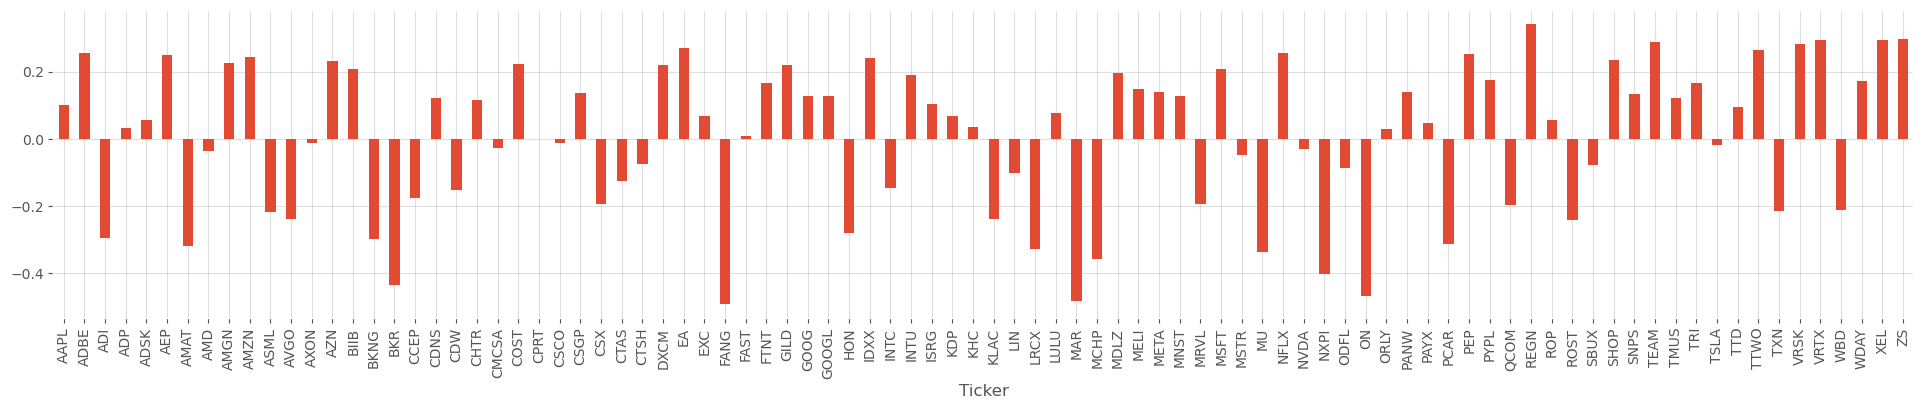

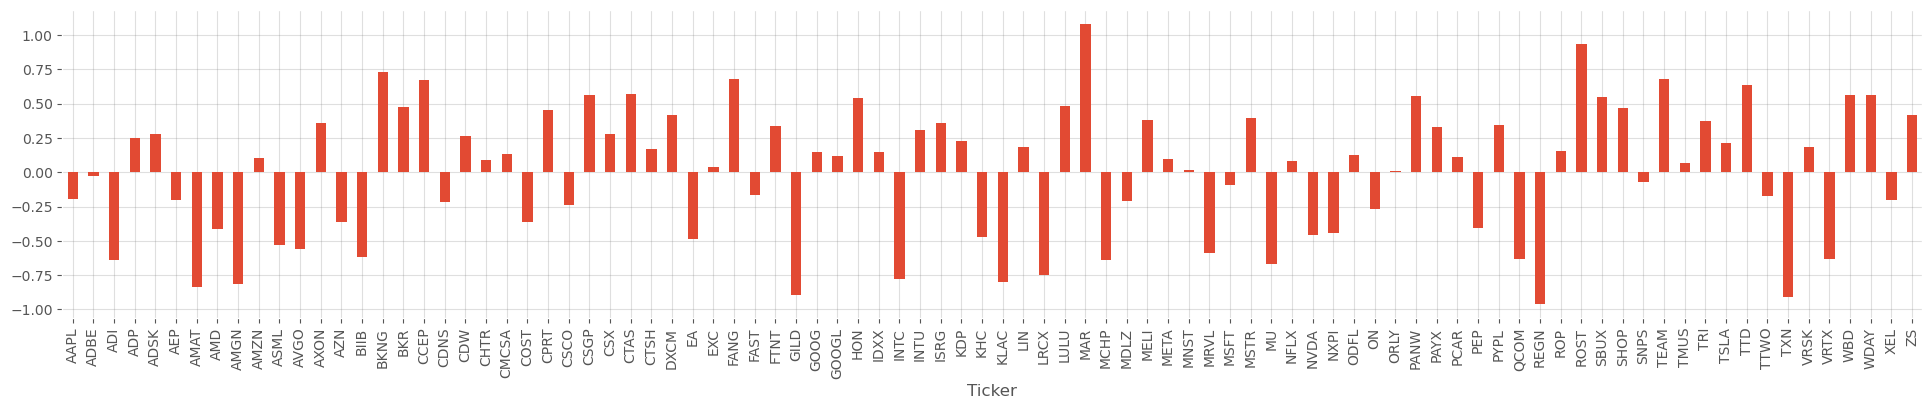

In [29]:
# plot weights of PCs
for weight in weights[:4]:
    pd.Series(weight,index=df.index).plot(kind='bar',figsize=[24,4])
    plt.show()

### <font color = blue> 👉 Questions 3. Using `yfinance`, extract the stock prices of the following ticker symbols, between July 2015 and June 2019.

- General Motors `GM`
- Marriott `MAR`
- Pfizer `PFE`
- ExxonMobil `XOM`
- The Walt Disney Company `DIS`
- Bank of America `BAC`
- Proctor & Gamble `PG`
- Hilton `HLT`
- Walmart `WMT`
- Twitter `TWTR`

### Then, calculate simple daily percentage changes in the stock prices, and store them into an object, printing the results into an output cell.

### Below are the lines of code that lead to an answer:

In [30]:
tickers = [
            'GM',
            'MAR',
            'PFE',
            'XOM',
            'DIS',
            'BAC',
            'PG',
            'HLT',
            'WMT',
            'TWTR',
]

In [40]:
# TODO yf download
stock_data=\
yf.download(
    tickers,
    start = '2015-01-01',
    end = '2019-07-01'
)['Close']


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_58780/2508606953.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  10 of 10 completed

1 Failed download:
['TWTR']: YFTzMissingError('possibly delisted; no timezone found')


In [41]:

stock_data = stock_data.pct_change().loc['2015-07-01':].drop(columns=['TWTR'])

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_58780/1557493720.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stock_data = stock_data.pct_change().loc['2015-07-01':].drop(columns=['TWTR'])


### <font color = red> Answer 3 is presented in the cell below: </font>

In [42]:
stock_data

Ticker,BAC,DIS,GM,HLT,MAR,PFE,PG,WMT,XOM
Date,,,,,,,,,
2015-07-01,0.011751,0.014540,-0.008701,0.008349,0.008066,0.004772,0.018916,0.013393,-0.009976
2015-07-02,-0.011034,-0.001390,0.005751,0.000000,-0.002534,-0.009498,0.002635,-0.000278,0.009348
2015-07-06,-0.005285,0.006349,-0.017454,0.000720,-0.006551,-0.003596,0.001501,0.009324,-0.007337
2015-07-07,-0.014758,0.012100,0.006432,0.001799,0.015207,0.014436,0.020862,0.017372,0.004120
2015-07-08,-0.026363,-0.016311,-0.050822,-0.022980,-0.019618,-0.008301,-0.008933,-0.009893,-0.010860
...,...,...,...,...,...,...,...,...,...
2019-06-24,-0.004979,-0.007202,0.001083,-0.006553,-0.002262,0.002061,0.010162,0.000990,-0.009525
2019-06-25,-0.007863,0.005171,0.019481,-0.023662,-0.025446,0.000000,-0.005430,-0.004675,-0.008837
2019-06-26,0.005403,0.003287,0.011943,0.013619,0.017782,-0.017596,-0.017812,-0.005058,0.004327


### <font color = blue> 👉 Questions 4. Using a box-and-whisker plot, compare the performance of the stocks over the given period of time. Find the stock with the highest variability and risk, based on the visualization.

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 4 is presented in the cell below: </font>

<AxesSubplot:>

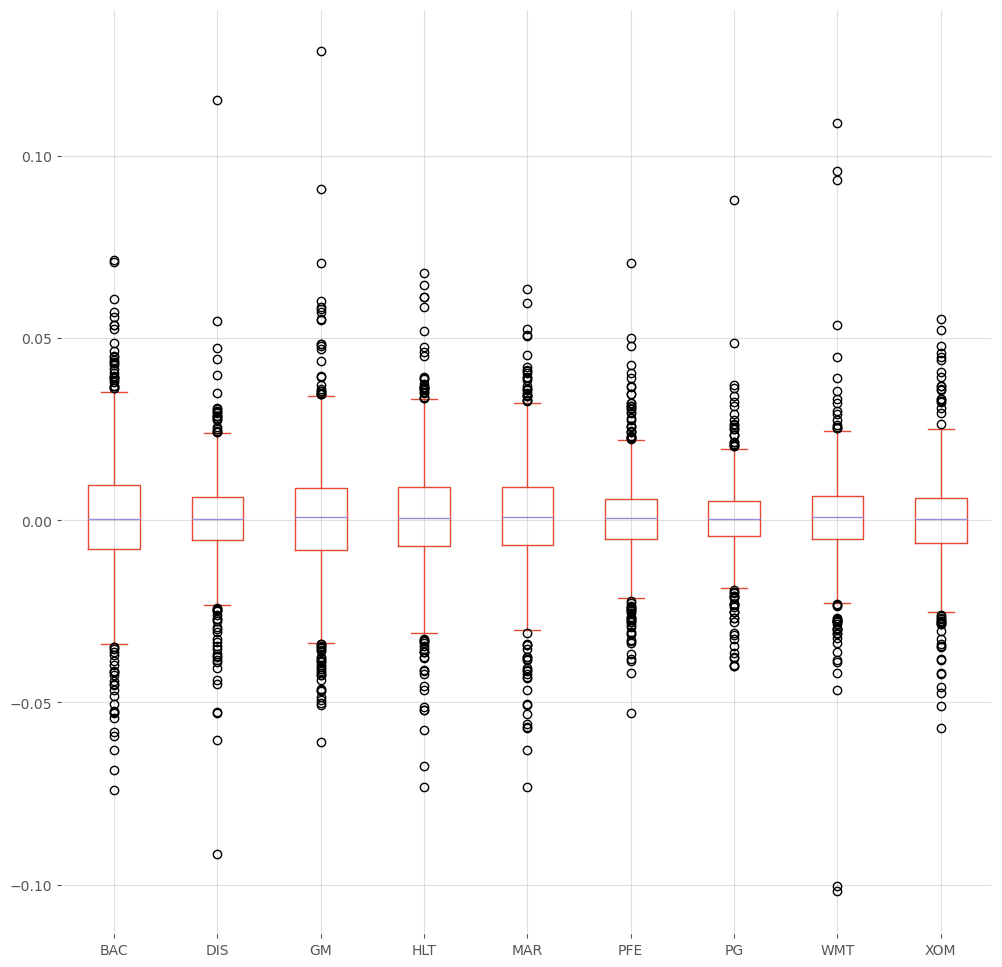

In [45]:
stock_data.plot(kind='box', figsize=[12,12])

### <font color = blue> 👉 Questions 5. Create your own function to compare daily percentage changes between stocks, using a scatter plot and its distribution relative to a perfect diagonal (regression line). 

### Assess which of the following pairs seem to show the closest relationships.

1. ExxonMobil (`XOM`) and General Motors (`GM`)
2. Twitter (`TWTR`) and The Walt Disney Company (`DIS`)
3. Marriott (`MAR`) and Hilton (`HLT`)
4. Pfeizer (`PFE`) and Proctor & Gamble (`PG`)
5. Bank of America (`BAC`) and Walmart (`WMT`)

### Upon completion of the above, please execute more tasks for the sake of this question. 

### As you have learned in class, if you wish to look for all combinations of stocks you can use the scatter matrix graph provided by the `pandas` module. Create the scatter matrix, along with a Kernel Density Estimation on the diagonal.

### Below are the lines of code that lead to an answer:

In [62]:
pairs = [
            ['XOM', 'GM'],
            ['MAR', 'HLT'],
            ['PFE', 'PG'],
            ['BAC', 'WMT']
            ]
        

In [63]:
def get_relationship(cols):
    rets = stock_data[cols].dropna()
    
    plt.scatter(rets[rets.columns[0]],rets[rets.columns[1]])
    r_min = rets.min().min()
    r_max = rets.max().max()

    np.linspace(r_min, r_max, 100)
    # rets.plot(kind='scatter')
    
    ln_x = np.linspace(r_min, r_max, 100)
    ln_y = np.linspace(r_min, r_max, 100)
    plt.plot(ln_x, ln_y, 'b--')
    
    corr_value = rets[cols[0]].corr(rets[cols[1]])
    print(f"Correlation between {cols[0]} and {cols[1]}: {corr_value:.4f}")
    plt.title(f"{cols[0]} vs {cols[1]}")
    plt.xlabel(cols[0])
    plt.ylabel(cols[1])
    plt.show()

# pair = ['XOM','GM']
# find_relationship(pair)

### <font color = red> Answer 5 is presented in the cell below: </font>

Correlation between XOM and GM: 0.3214


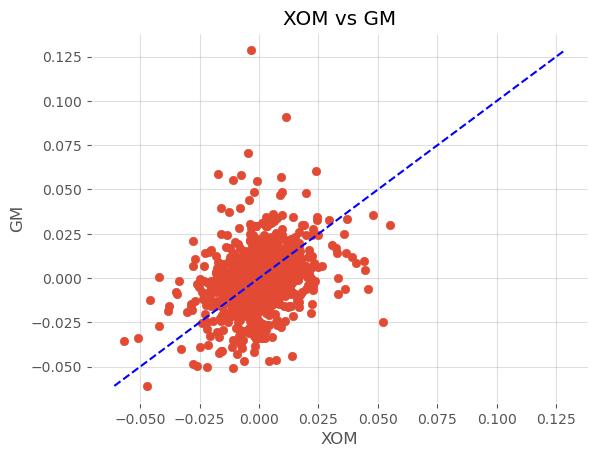

Correlation between MAR and HLT: 0.7889


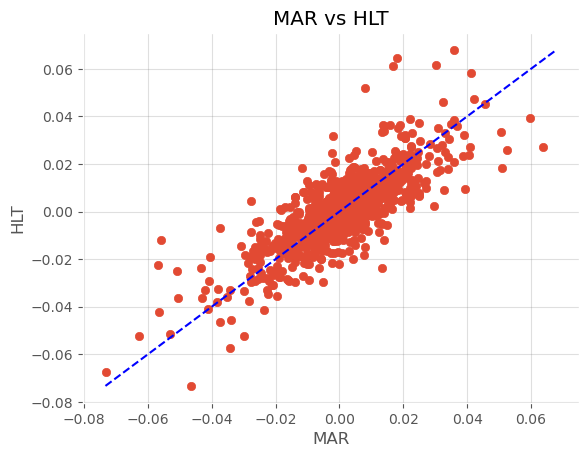

Correlation between PFE and PG: 0.3364


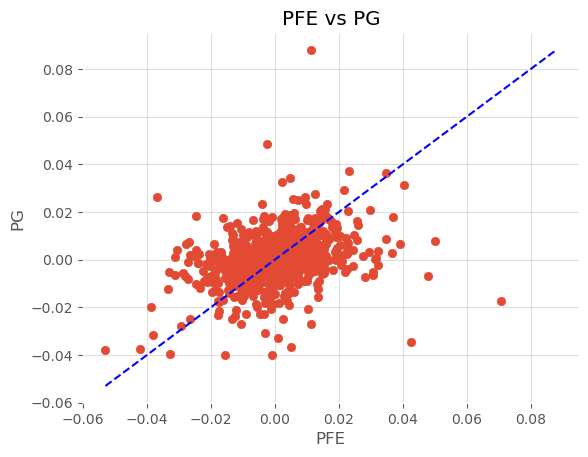

Correlation between BAC and WMT: 0.1995


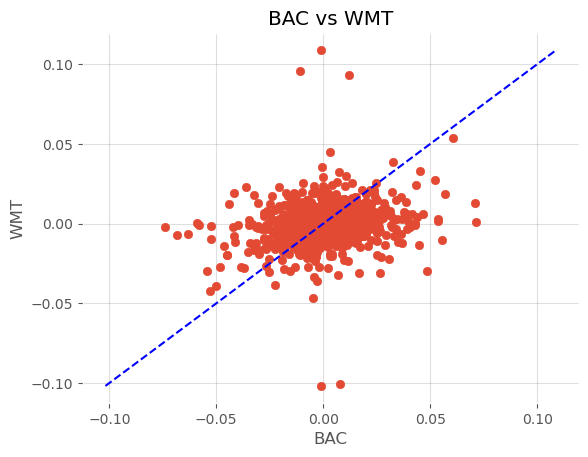

In [65]:
for pair in pairs:
    get_relationship(pair)
    

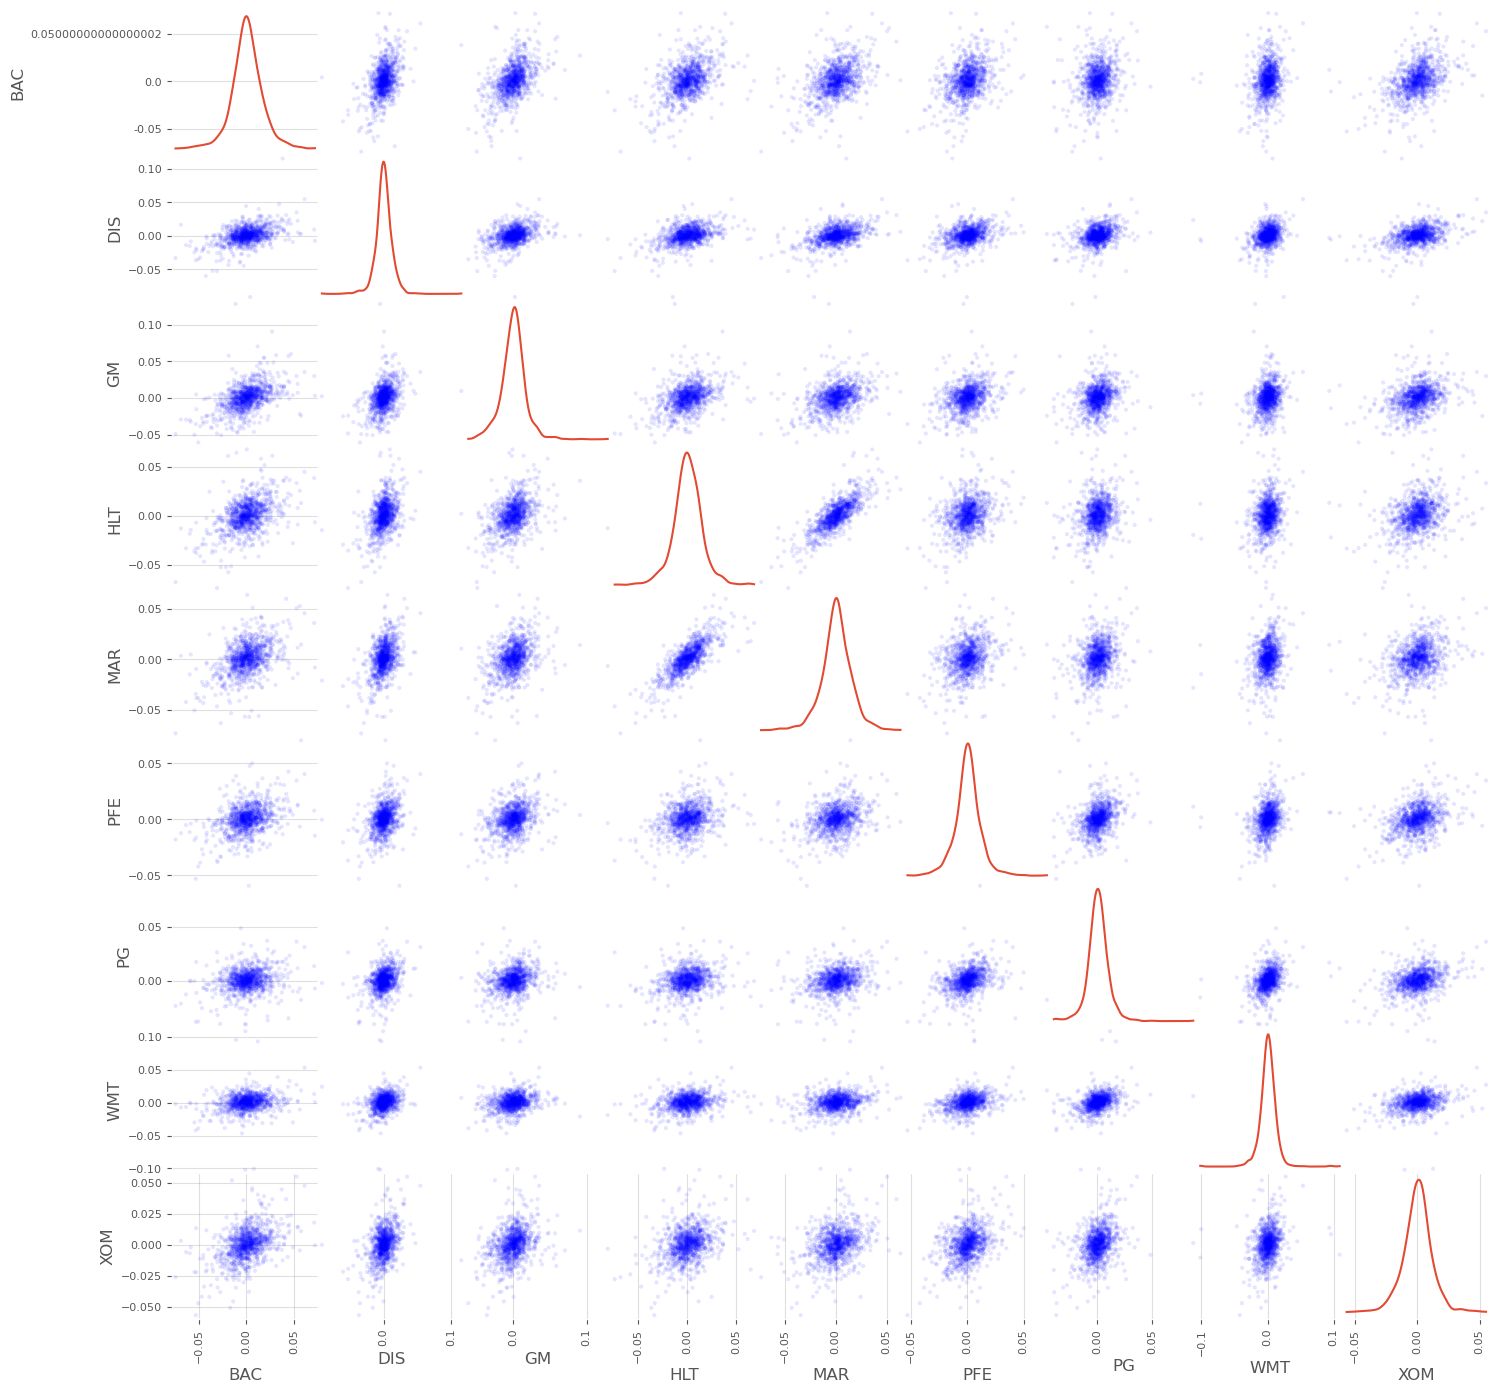

In [67]:
pd.plotting\
        .scatter_matrix(stock_data,
                    diagonal = "kde", # Kernel Density Estimation
                    color = "blue",
                    alpha = 0.10,
                    figsize = [17 ,17]
                   );

### <font color = blue> 👉 Question 6. It is often useful to analyze stock performance against a market index such as the S&P 500. This will give a sense of how a stock price compares to movements in the overall market.

### Carry out the following analysis steps.

<font color = green>

> ### 1. Extract the S&P 500 (`^GSPC`) data for the same time period used for the stocks in Question 1.

> ### 2. In order to perform comparisons, you must run the same calculations to derive the daily percentage changes and cumulative returns on the index. You might first want to concatenate the index calculations in the results of the calculations of the stocks with respect to daily percentage changes. The process will lead you to efficiently compare the overall set of stocks and index calculations for daily percentage changes.

> ### 3. Calculate the cumulative daily returns.

> ### 4. To complete this analysis, calculate the correlation of the daily percentage change values.

> ### 5. Using location accessor, print only the correlational coefficients of each stock relative to the S&P 500, in descending order.

</font> 
        
### Which stock price moved in the most similar way to the S&P 500? Which moved in the least similar way?

### Below are the lines of code that lead to an answer:

In [68]:
# TODO yf download
stock_data=\
yf.download(
    tickers + ['^GSPC'],
    start = '2015-01-01',
    threads=True
)['Close']


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_58780/1897698003.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  11 of 11 completed

1 Failed download:
['TWTR']: YFTzMissingError('possibly delisted; no timezone found')


In [72]:
stock_data = stock_data.drop(columns='TWTR')

In [74]:
stock_data = stock_data.pct_change().dropna()

In [76]:
daily_returns = stock_data
cum_returns = (stock_data + 1).cumprod()

In [81]:
corrs = daily_returns.corr()[daily_returns.columns[-1]].sort_values(ascending=False)

### <font color = red> Answer 6 is presented in the cell below: </font>

In [84]:
f"most similar way = {corrs.index[1]}. least similar way = {corrs.index[-1]}"

'most similar way = BAC. least similar way = WMT'

### <font color = blue> 👉 Question 7. One common type of data visualization in finance is a stock’s trading volume relative to its closing price.

### Create a chart below after obtaining the data from Yahoo Finance!, using `yfinance`. The target symbol is `AMZN`, and our period of interest is between January 2007 and December 2009. 

### Below are the lines of code that lead to an answer:

In [85]:
# TODO yf download
stock_data=\
yf.download(
    ['AMZN'],
    start = '2006-12-01',
    end = '2010-12-01'
)[['Close','Volume']]


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_58780/1778430304.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  1 of 1 completed


In [108]:
amzn_data = stock_data.droplevel(level='Ticker', axis=1)

### <font color = red> Answer 7 is presented in the cell below: </font>

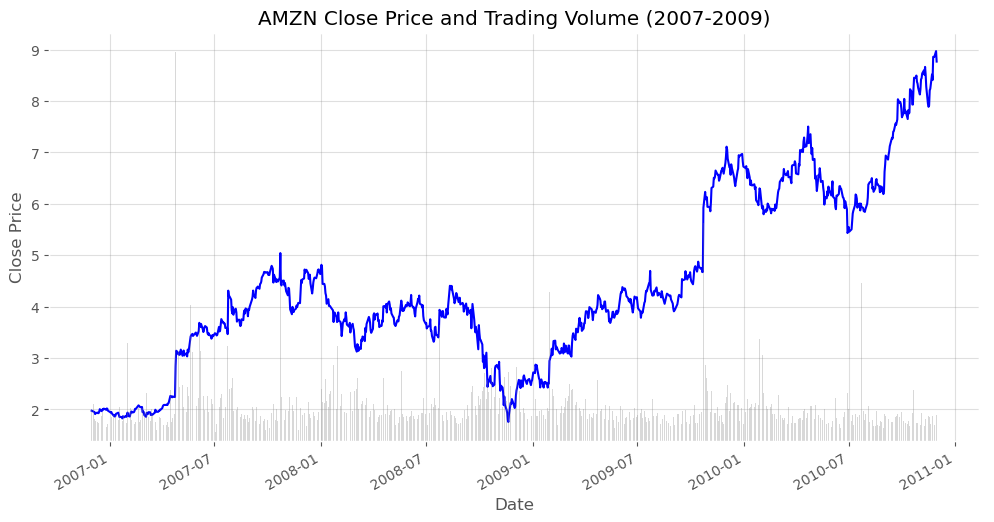

In [109]:

ax = amzn_data['Close'].plot(figsize=(12,6), color='blue', label='Close')

# Plot Volume as bar on secondary y-axis
ax2 = ax.twinx()
ax2.bar(amzn_data.index, amzn_data['Volume'], color='gray', alpha=0.3, label='Volume')

# --- Remove the secondary y-axis ticks and labels ---
ax2.yaxis.set_visible(False)
# --- Remove the secondary grid (still useful if you keep the y-axis labels) ---
ax2.grid(False)

# Labels and title
ax.set_ylabel("Close Price")
ax2.set_ylabel("Volume")
plt.title("AMZN Close Price and Trading Volume (2007-2009)")
plt.show()


## 👇 <font color = "purple"> Bigger Question 8. 

### Please create a predictive model for the weekly return of NFLX stock. You will use supervised learning for your predictive modelling.

> As you learned in class, to do this it is essential to know what factors are related to Netflix’s stock price, and to incorporate as much information as you can into the model.

> Among the three major factors (correlated assets, technical indicators, and fundamental analysis), you will use correlated assets and technical indicators as features here.

    Step 1. Use 75% of your data for the training of your algorithm, and 25% for the testing set.

    Step 2. For your feature engineering...
    
> Our operational definition of `outcome` (`Y`) is the weekly return of Netflix (NFLX). The number of trading days in a week is assumed to be five, and we compute the return using five trading days. 
<br>
    
* <font color = "green"> NOTE: The lagged five-day variables embed the time series component by using a time-delay approach, where the lagged variable is included as one of the predictor variables. This step translates the time series data into a supervised regression-based model framework.
<br>    
    
> For `input features` (`predictors`; `Xs`), we use (The variables used as predictors are as follows) ...

> `Correlated assets`

* lagged five-day returns of stocks (META, APPLE, AMZN, GOOGL);
* currency exchange rates (USD/JPY and GBP/USD);
* indices (S&P 500, Dow Jones, and VIX);
* lagged five-day, 15-day, 30-day, and 60-day returns of NFLX.

> `Technical indicators`

* 21-day, 63-day, and 252-day moving averages;
* 10-day, 30-day, and 200-day exponential moving averages;
* 10-day, 30-day, and 200-day relative strength index;
* stochastic oscillator %K and %D (using rolling windows of 10-, 30-, 200-day);
* rate of change (using 10-, 30-day past prices).
    
    
    Step 3. For your algorithm of choices, please assess the model performance of the following algorithms: 

    
* Linear Regression
* Elastic Net
* LASSO
* Support Vector Machine
* K-Nearest Neighbor
* ARIMA
* Decision Tree
* Extra Trees 
* Random Forest
* Gradient Boosting Tree
* Adaptive Boosting
    
    
    Step 4. For this exercise, hyperparameter tuning is not requested. 
    
    Step 5. But make sure to compare the model performance of the above algorithms.

> The metric for assessing model performance will be mean squared error (`MSE`).
<br>

> Show which of the algorithms perform relatively better by a comparison visualization of performance, for both the training and testing sets learned in class. 

    Step 6. Using the model of your choice, please visualize the actual vs. predicted (estimated) data.

### Below are the lines of code that lead to an answer:

In [111]:
target = 'NFLX'
stock_tickers = [
    "NFLX", "AMZN", "AAPL", "META", "GOOGL"    # Stocks
]
index_tickers = [
    "^GSPC", "^DJI", "^VIX"        # Indices
]
ccy_tickers = [
    "JPY=X", "GBPUSD=X"           # FX rates
]
sub_df_list = stock_tickers + index_tickers + ccy_tickers

ticker_data =\
(
    yf.download(
        sub_df_list,
        start = dt.datetime(2013, 1, 7),
        auto_adjust=False
    )
)['Adj Close']
# remove nulls
ticker_data = ticker_data.ffill()

[*********************100%***********************]  10 of 10 completed


### <font color = red> Answer 8 is presented in the cell below: </font>

In [112]:
sub_df_list = []

# 5 day lags for all stocks
df_rets = ticker_data[[ticker for ticker in stock_tickers if ticker != target]].copy() # remove target
lag = 5
df_rets = df_rets.pct_change(lag).shift(1).rename(columns={f'{ticker}':f'{ticker}_ret_{lag}' for ticker in stock_tickers})

sub_df_list.append(df_rets)

In [113]:
# get ccy 
sub_df_list.append(ticker_data[ccy_tickers].copy())
# get indices
sub_df_list.append(ticker_data[index_tickers].copy())

In [114]:

# lagged five-day, 15-day, 30-day, and 60-day returns of NFLX.
lag_list = [5, 15, 30, 60]
df_rets = ticker_data[[target]].copy()

for lag in lag_list:
    df_rets[f'{target}_ret_{lag}'] = df_rets[target].pct_change(lag).shift(1)
    
df_rets = df_rets.drop(columns=target)

sub_df_list.append(df_rets)

In [115]:
# get sma
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window,
                     min_periods = int(window * .8))
            .mean()
        )

    return df

sma_list = [21, 63, 252]
df_sma = get_sma(ticker_data[[target]].copy(), sma_list).drop(columns=target)

sub_df_list.append(df_sma)



In [116]:
# get EMA
def get_ema(df, ema_list):
    """
    Take DF and given list of EMA to enrich df when stock price is in first column
    """
    for window in ema_list:
        df[f"ema_{window}"] =\
        (
            df[df.columns[0]]
            .ewm(span = window)
            .mean()
        )

    return df

ema_list = [10, 30, 200]
df_ema = get_ema(ticker_data[[target]].copy(), ema_list).drop(columns=target)

sub_df_list.append(df_ema)

In [117]:
# get RSI
def get_rsi(df, period_list=[10, 30, 200]):
    """
    Calculate RSI (Relative Strength Index)
    
    Parameters:
    data: pandas df of closing price
    period: RSI period (default [10, 20, 200])
    
    Returns:
    pandas df with RSI values
    """
    # Calculate price changes
    delta = df[df.columns[0]].diff()
    
    for period in period_list:
        # Separate gains and losses
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        
        # get first average
        avg_gain = pd.Series(index=df.index, dtype='float64')
        avg_loss = pd.Series(index=df.index, dtype='float64')

        # get first average
        avg_gain.iloc[period] = gain.iloc[1:period+1].mean()    # start from period + 1 since diff() makes first NaN
        avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

        # Calculate rolling averages
        for i in range(period + 1, len(df)): 
            avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + gain.iloc[i]) / period
            avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + loss.iloc[i]) / period

        # Calculate RS (Relative Strength)
        rs = avg_gain / avg_loss
        
        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))

        df[f'rsi_{period}'] = rsi

    return df

rsi_list = [10, 30, 200]
df_rsi = get_rsi(ticker_data[[target]].copy(), rsi_list).drop(columns=target)

sub_df_list.append(df_rsi)

In [118]:
# get_stochastic_oscillator
def get_stochastic_oscillator(ticker, start, end, period_list=[10, 30, 200]):
    """
    Get the stochastic oscillator for a given stock.
    """
    def STOK(close, low, high, n):
        STOK = ((close - low.rolling(n).min()) / \
                (high.rolling(n).max() - low.rolling(n).min()
                )
            ) * 100
        return STOK

    def STOD(close, low, high, n):
        STOK = ((close - low.rolling(n).min()) / \
                (high.rolling(n).max() - low.rolling(n).min()
                )
            ) * 100
        
        STOD = STOK.rolling(3).mean()
        return STOD

    df = yf.download(
                        ticker,
                        start=start,
                        end=end
                    ).droplevel('Ticker',axis=1)

    for period in period_list:
        df[f"%K{period}"] = STOK(df["Close"], df["Low"], df["High"], period)
        df[f"%D{period}"] = STOD(df["Close"], df["Low"], df["High"], period)

    return df.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume'])

kd_list=[10, 30, 200]
df_kd = get_stochastic_oscillator(target, ticker_data.index[0], ticker_data.index[-1], kd_list)

sub_df_list.append(df_kd)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_58780/1249423668.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


In [119]:
# Rate of Change (RoC)
def get_roc(df, period_list):
    """
    Calculate the Rate of Change (RoC) for a given DataFrame and period.
    """
    for period in period_list:
        M = df[df.columns[0]].diff(period - 1)
        N = df[df.columns[0]].shift(period - 1)
        df[f"roc_{period}"] = (M / N) * 100

    return df

roc_list = [10, 30]
df_roc = get_roc(ticker_data[[target]].copy(), [10, 30]).drop(columns=target)

sub_df_list.append(df_roc)

In [120]:
# y parameter
fwd = 5
df_fwd_rets = ticker_data[[target]].copy()

df_fwd_rets[f"{target}_fwd_rets"] = df_fwd_rets.pct_change(fwd).shift(-fwd-1) 
                        # get fwd rets, shift by same amount, only trade day after signal computed
    
df_fwd_rets = df_fwd_rets.drop(columns=target)
sub_df_list.append(df_fwd_rets)

In [121]:
# combine df
df =\
(
    pd.concat(sub_df_list,axis=1)
)
# fill forward for NaN
df =\
(
    df.ffill().dropna()
)

In [122]:
X = df.drop(columns=[f'{target}_fwd_rets'])
y = df[[f'{target}_fwd_rets']]

In [123]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=False)

[ a.shape for a in [X_train, X_test, y_train, y_test ]]

[(2355, 30), (786, 30), (2355, 1), (786, 1)]

In [124]:
from sklearn.metrics import mean_squared_error

mse_results = {}

def get_mse_train_test(model, X_train, y_train, X_test, y_test, name=None):
    """
    Compute MSE on train and test and store results in mse_results.
    If name is not provided, use model class name.
    """
    global mse_results
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)

    model_name = name or model.__class__.__name__
    if model_name == "GridSearchCV":
        model_name = str(type(model.best_estimator_)).split(".")[-1].replace("'>", "")
    mse_results[str(model_name)] = {'mse_train': mse_train, 'mse_test': mse_test}

    print(f"Mean Squared Error (MSE) for {model_name}")
    print(f"MSE train: {mse_train:.6f}")
    print(f"MSE test: {mse_test:.6f}")

    return mse_train, mse_test

In [125]:
## Linear regression
import statsmodels.api as sm

# Ensure X_train is a DataFrame with column names
X_train_df = sm.add_constant(X_train)
X_test_df = sm.add_constant(X_test) # Add intercept

lr = sm.OLS(y_train, X_train_df).fit()
display(lr.summary())
get_mse_train_test(lr, 
                   X_train_df, 
                   y_train, 
                   X_test_df,
                   y_test, 
                   name="LR")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          NFLX_fwd_rets   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     6.357
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           3.95e-24
Time:                        17:59:36   Log-Likelihood:                 3239.3
No. Observations:                2355   AIC:                            -6417.
Df Residuals:                    2324   BIC:                            -6238.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0220      0.053      0.418      0.676      -0.081       0.125
AMZN_ret_5     -0.0157      0.040     -0.395      0.693      -0.094       0.062
AAPL_ret_5      0.0341      0.044      0.769      0.442      -0.053       0.121
META_ret_5     -0.0177      0.036     -0.496      0.620      -0.088       0.052
GOOGL_ret_5     0.1613      0.054      2.962      0.003       0.055       0.268
JPY=X          -0.0007      0.000     -3.008      0.003      -0.001      -0.000
GBPUSD=X       -0.0133      0.017     -0.770      0.441      -0.047       0.021
^GSPC       -3.057e-05   1.22e-05     -2.510      0.012   -5.45e-05   -6.69e-06
^DJI         8.341e-06      2e-06      4.161      0.000    4.41e-06    1.23e-05
^VIX            0.0018      0.000      6.738      0.000       0.001       0.002
NFLX_ret_5     -0.0895      0.036     -2.477      0.013      -0.160      -0.019
NFLX_ret_15     0.0231      0.028      0.823      0.411      -0.032       0.078
NFLX_ret_30     0.0663      0.032      2.056      0.040       0.003       0.130
NFLX_ret_60    -0.0355      0.015     -2.367      0.018      -0.065      -0.006
sma_21         -0.0012      0.001     -1.767      0.077      -0.002       0.000
sma_63       1.286e-05      0.000      0.035      0.972      -0.001       0.001
sma_252         0.0010      0.000      4.671      0.000       0.001       0.001
ema_10         -0.0004      0.000     -0.996      0.319      -0.001       0.000
ema_30          0.0023      0.001      1.875      0.061      -0.000       0.005
ema_200        -0.0021      0.000     -5.989      0.000      -0.003      -0.001
rsi_10          0.0017      0.001      3.480      0.001       0.001       0.003
rsi_30       9.877e-05      0.001      0.113      0.910      -0.002       0.002
rsi_200        -0.0011      0.001     -1.035      0.301      -0.003       0.001
%K10           -0.0001      0.000     -0.851      0.395      -0.000       0.000
%D10         6.886e-05      0.000      0.370      0.711      -0.000       0.000
%K30           -0.0002      0.000     -0.566      0.571      -0.001       0.000
%D30           -0.0005      0.000     -1.551      0.121      -0.001       0.000
%K200          -0.0002      0.001     -0.219      0.827      -0.002       0.001
%D200           0.0001      0.001      0.191      0.849      -0.001       0.002
roc_10         -0.0007      0.000     -2.191      0.029      -0.001    -7.8e-05
roc_30         -0.0007      0.000     -1.922      0.055      -0.001    1.33e-05
==============================================================================
Omnibus:                      221.502   Durbin-Watson:                   0.441
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1566.308
Skew:                          -0.003   Prob(JB):                         0.00
Kurtosis:                       6.995   Cond. N

Mean Squared Error (MSE) for LR
MSE train: 0.003739
MSE test: 0.006680


(0.003739253911690259, 0.006679985584619071)

In [126]:
# ----------------------------------------------------------------------------
# 1. ELASTIC NET
# ----------------------------------------------------------------------------
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=1000, random_state=42)
elastic_net.fit(X_train, y_train)
y_pred_en = elastic_net.predict(X_test)
print(f"Elastic Net - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_en)):.4f}")
# # Hyperparameter tuning
# param_grid_en = {
#     'alpha': [0.01, 0.1, 10.0],
#     'l1_ratio': [0.1, 0.9]
# }
# grid_en = GridSearchCV(ElasticNet(max_iter=1000), param_grid_en, cv=5, scoring='neg_root_mean_squared_error')
# grid_en.fit(X_train, y_train)
# print(f"Best Elastic Net params: {grid_en.best_params_}")
# metrics
mse_train, mse_test = get_mse_train_test(elastic_net, X_train, y_train, X_test, y_test)

Elastic Net - RMSE: 0.0791
Mean Squared Error (MSE) for ElasticNet
MSE train: 0.003808
MSE test: 0.006250


/Users/ju/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.980e+00, tolerance: 9.529e-04
  model = cd_fast.enet_coordinate_descent(


In [127]:
# ----------------------------------------------------------------------------
# 2. LASSO
# ----------------------------------------------------------------------------
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=1000, random_state=42)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print(f"LASSO - MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")

# Feature selection with LASSO
n_nonzero = np.sum(lasso.coef_ != 0)
# print(f"LASSO selected {n_nonzero} features out of {X_reg.shape[1]}")

mse_train, mse_test = get_mse_train_test(lasso, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

LASSO - MSE: 0.0041
Mean Squared Error (MSE) for Lasso
MSE train: 0.003855
MSE test: 0.004064


/Users/ju/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.524e-02, tolerance: 9.529e-04
  model = cd_fast.enet_coordinate_descent(


In [128]:
# ----------------------------------------------------------------------------
# 3. SUPPORT VECTOR MACHINE (Regression)
# ----------------------------------------------------------------------------
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train, y_train.values.ravel())
y_pred_svr = svr.predict(X_train)
print(f"SVR - RMSE: {np.sqrt(mean_squared_error(y_train.values.ravel(), y_pred_svr)):.4f}")

# Hyperparameter tuning
# param_grid_svr = {
#     'C': [0.1],
#     'epsilon': [0.01, 0.1],
#     'kernel': ['linear']
# }
# grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='neg_root_mean_squared_error')
# grid_svr.fit(X_train, y_train.values.ravel())  # Uncomment to run
# print(f"Best SVR params: {grid_svr.best_params_}")

mse_train, mse_test = get_mse_train_test(svr, 
                                         X_train, 
                                         y_train.values.ravel(), 
                                         X_test, 
                                         y_test.values.ravel())

SVR - RMSE: 0.0633
Mean Squared Error (MSE) for SVR
MSE train: 0.004002
MSE test: 0.007581


In [129]:
# ----------------------------------------------------------------------------
# 4. K-NEAREST NEIGHBOR (Regression)
# ----------------------------------------------------------------------------
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform')
knn_reg.fit(X_train, y_train)
y_pred_knn = knn_reg.predict(X_train)
print(f"KNN Regressor - RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_knn)):.4f}")

# Find optimal k
# param_grid_knn = {'n_neighbors': range(1, 21)}
# grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='neg_root_mean_squared_error')
# grid_knn.fit(X_train, y_train)
# print(f"Best k: {grid_knn.best_params_['n_neighbors']}")

mse_train, mse_test = get_mse_train_test(knn_reg, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

KNN Regressor - RMSE: 0.0454
Mean Squared Error (MSE) for KNeighborsRegressor
MSE train: 0.002066
MSE test: 0.007499


In [130]:
# ============================================================================
# 10. ARIMA (Time Series)
# ============================================================================
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.arima.model as stats
import warnings
warnings.filterwarnings('ignore')

baseline_ARIMA =\
(
    stats
    .ARIMA(endog = y_train,
           exog = X_train,
           order = [1, 0, 0]
          )
)
arima = baseline_ARIMA.fit()
[key for key in mse_results.keys() ]
y_pred_arima = arima.predict(
    start = 0,
    end = X.shape[0] -1,
    exog = X_test
)

# y_pred_arima
mse_train = \
(
    mean_squared_error(y_train,
                       y_pred_arima[:len(y_train)])
)
mse_test = \
(
    mean_squared_error(y_test,
                       y_pred_arima[-len(y_test):])
)
name = getattr(arima, 'name', None) or arima.__class__.__name__
mse_results[name] = {'mse_train': mse_train, 'mse_test': mse_test}

In [131]:
# ----------------------------------------------------------------------------
# 5. DECISION TREE
# ----------------------------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(f"Decision Tree - MSE: {mean_squared_error(y_test, y_pred_dt):.4f}")

# Feature importance
feature_importance_dt = pd.DataFrame({
    'feature': [f'feature_{i}' for i in range(X_train.shape[1])],
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)
print("Top 5 important features (DT):")
print(feature_importance_dt.head())

mse_train, mse_test = get_mse_train_test(dt, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

Decision Tree - MSE: 0.0240
Top 5 important features (DT):
       feature  importance
15  feature_15    0.091902
16  feature_16    0.084310
18  feature_18    0.082779
27  feature_27    0.070268
8    feature_8    0.065447
Mean Squared Error (MSE) for DecisionTreeRegressor
MSE train: 0.002060
MSE test: 0.024020


In [132]:
# ----------------------------------------------------------------------------
# 6. EXTRA TREES
# ----------------------------------------------------------------------------
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
print(f"Extra Trees - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_et)):.4f}")

mse_train, mse_test = get_mse_train_test(et, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

Extra Trees - RMSE: 0.0851
Mean Squared Error (MSE) for ExtraTreesRegressor
MSE train: 0.001242
MSE test: 0.007238


In [133]:
# ----------------------------------------------------------------------------
# 7. RANDOM FOREST
# ----------------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, 
       y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

# # Hyperparameter tuning (commented out - uncomment to run)
# param_grid_rf = {
#     'n_estimators': [50, 200],
#     'max_depth': [5, 10],
#     'min_samples_split': [5, 10]
# }
# grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
#                        param_grid_rf, cv=3, scoring='neg_root_mean_squared_error')
# grid_rf.fit(X_train, y_train)
# print(f"Best RF params: {grid_rf.best_params_}")

mse_train, mse_test = get_mse_train_test(rf, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

Random Forest - RMSE: 0.1199
Mean Squared Error (MSE) for RandomForestRegressor
MSE train: 0.001652
MSE test: 0.014369


In [134]:
# ----------------------------------------------------------------------------
# 8. GRADIENT BOOSTING TREE
# ----------------------------------------------------------------------------
from sklearn.ensemble import GradientBoostingRegressor

gbt = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbt.fit(X_train, y_train)
y_pred_gbt = gbt.predict(X_test)
print(f"Gradient Boosting - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gbt)):.4f}")

mse_train, mse_test = get_mse_train_test(gbt, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

Gradient Boosting - RMSE: 0.1102
Mean Squared Error (MSE) for GradientBoostingRegressor
MSE train: 0.001822
MSE test: 0.012142


In [135]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print(f"AdaBoost - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ada)):.4f}")

mse_train, mse_test = get_mse_train_test(ada, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

AdaBoost - RMSE: 0.0613
Mean Squared Error (MSE) for AdaBoostRegressor
MSE train: 0.003195
MSE test: 0.003762


In [136]:
metrics = pd.DataFrame(mse_results).T.sort_values(by='mse_test')
metrics['mse_ratio'] = metrics['mse_test'] / metrics['mse_train']
metrics

,mse_train,mse_test,mse_ratio
AdaBoostRegressor,0.003195,0.003762,1.177489
Lasso,0.003855,0.004064,1.054361
ElasticNet,0.003808,0.006250,1.641324
LR,0.003739,0.006680,1.786449
ARIMAResultsWrapper,0.001467,0.006741,4.594701
ExtraTreesRegressor,0.001242,0.007238,5.827502
KNeighborsRegressor,0.002066,0.007499,3.630521
SVR,0.004002,0.007581,1.894657
GradientBoostingRegressor,0.001822,0.012142,6.665067
RandomForestRegressor,0.001652,0.014369,8.699048


In [137]:
comparison_df = \
pd.DataFrame({
    'Actual': y_test.values.flatten() if hasattr(y_test, 'values') else y_test,
    'Predicted': y_pred_en
}, index=y_test.index)

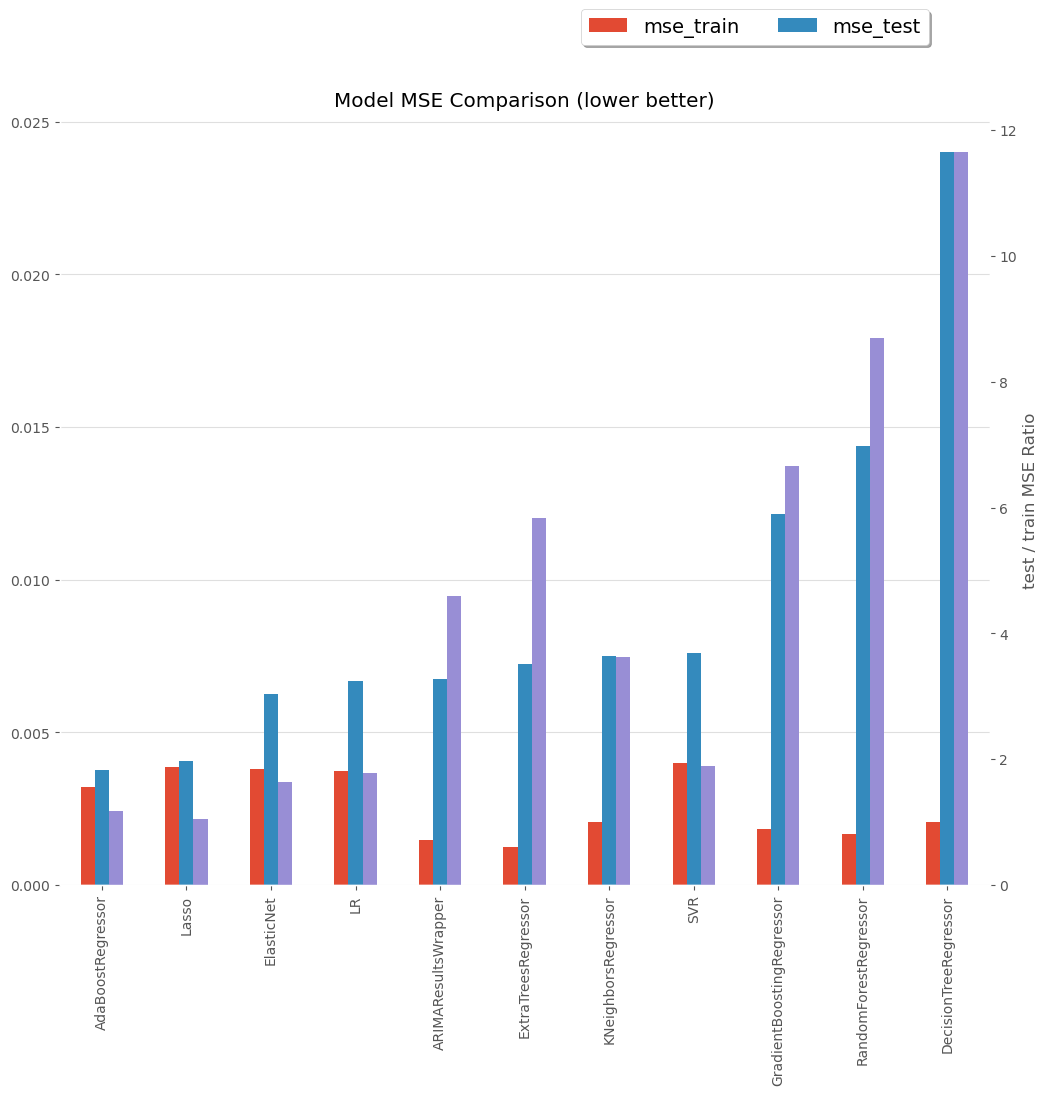

In [138]:
ax =\
(
    metrics.plot(
        secondary_y = 'mse_ratio',
        kind='bar',
        title='Model MSE Comparison (lower better)',
        ylabel='test / train MSE Ratio',
        figsize=(12, 10)
    )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper left",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

> 💯 “Thank you for putting your efforts into the individual assessment questions” 😊